<a href="https://colab.research.google.com/github/blagaiulia/BlagaIulia-IA-1-NLP/blob/main/InvatareAutomata_Tema2CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten
from keras.datasets import mnist
from keras.utils import to_categorical

np.random.seed(0)

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(x_train.shape)  # (60000, 28, 28)
print(x_test.shape)   # (10000, 28, 28)

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape for CNN (add channel dimension)
# (samples, height, width, channels)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print(x_train.shape)  # (60000, 28, 28, 1)

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

model = Sequential()

# Convolution layer 1
model.add(Conv2D(filters=32,
                 kernel_size=(3,3),
                 activation='relu',
                 input_shape=(28,28,1)))

# Max pooling
model.add(MaxPooling2D(pool_size=(2,2)))

# Convolution layer 2
model.add(Conv2D(filters=64,
                 kernel_size=(3,3),
                 activation='relu'))

# Max pooling
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Fully connected layer
model.add(Dense(128, activation='relu'))

# Dropout
model.add(Dropout(0.25))

# Output layer
model.add(Dense(10, activation='softmax'))

# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=10,
    verbose=1
)


test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test loss: {test_loss:.4f}")


(60000, 28, 28)
(10000, 28, 28)
(60000, 28, 28, 1)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 60ms/step - accuracy: 0.8432 - loss: 0.4990
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 59ms/step - accuracy: 0.9780 - loss: 0.0705
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 61ms/step - accuracy: 0.9843 - loss: 0.0509
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - accuracy: 0.9886 - loss: 0.0382
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - accuracy: 0.9906 - loss: 0.0296
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 62ms/step - accuracy: 0.9920 - loss: 0.0246
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 31s 65ms/step - accuracy: 0.9928 - loss: 0.0211
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 62ms/step - accuracy: 0.9935 - loss: 0.0196
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 60ms/step - accuracy: 0.9952 - loss: 0.0159
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 58ms/step - accuracy: 0.9961 - loss: 0.0122
Test accuracy: 0.9904
Test loss: 0.0303


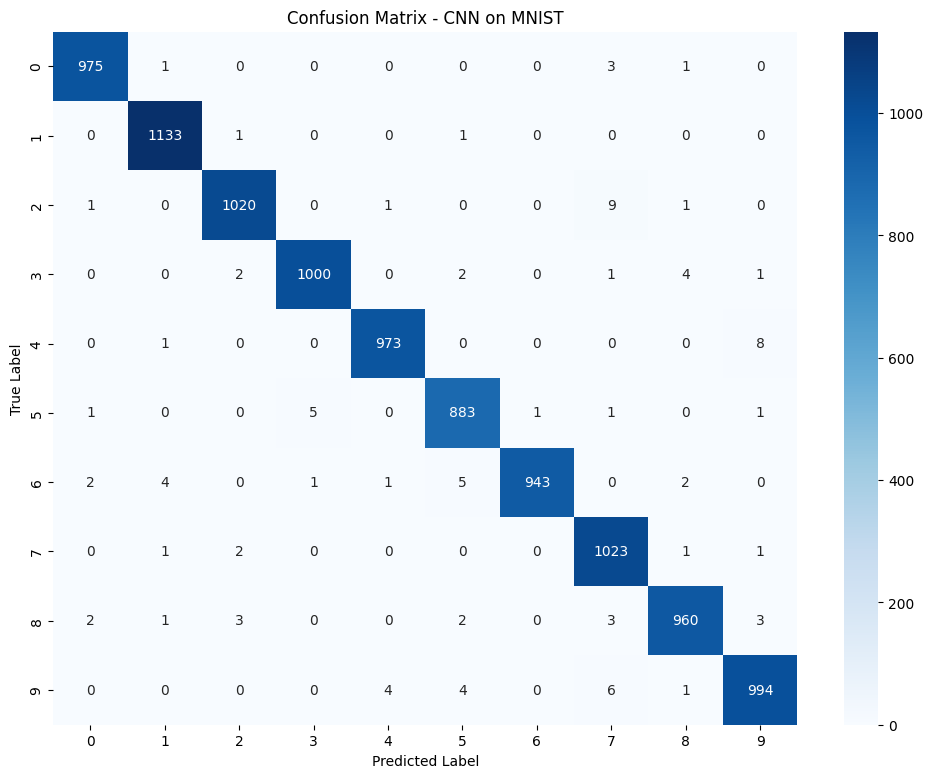

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Predict classes
y_pred = model.predict(x_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

# Make y_true numeric (0–9), regardless of its format
if len(np.array(y_test).shape) == 2:   # one-hot (10000, 10)
    y_true = np.argmax(y_test, axis=1)
else:                                  # numeric (10000,)
    y_true = y_test

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - CNN on MNIST")
plt.show()
